In [44]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu, norm
import matplotlib.pyplot as plt


In [82]:
ET_Time = {}
gender = {}
genderAndDev = {}
stars_All = {}
dev_lastANDtest = {}
df_RT_Stars_cleaned = {}
Dev_all_RT = {}
rt_stars_training = {}
for i in range (1, 6):
    stars_All[i] = pd.read_csv(rf'stars{i}.csv')
    dev_lastANDtest[i] = pd.read_csv(rf'dev_lastANDtest{i}.csv')
    df_RT_Stars_cleaned[i] = pd.read_csv(rf'df_RT_Stars_cleaned{i}.csv')
    Dev_all_RT[i] = pd.read_csv(rf'Dev_all_RT{i}.csv')
    rt_stars_training[i] = pd.read_csv(rf'rt_stars_training{i}.csv')

In [46]:
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers


In [47]:
all_times = pd.concat([ET_Time[2], ET_Time[3], ET_Time[4], ET_Time[5]]).set_index('subId') #ET_Time[1], 

In [48]:
stars_All = pd.concat([stars_All[1], stars_All[2], stars_All[3], stars_All[4], stars_All[5]]).set_index('subId') 

In [115]:
dev_lastANDtest = pd.concat([dev_lastANDtest[1], dev_lastANDtest[2], dev_lastANDtest[3], dev_lastANDtest[4], dev_lastANDtest[5]]).set_index('subId')#[dev_lastANDtest[1],  

In [83]:
df_RT_Stars_cleaned = pd.concat([df_RT_Stars_cleaned[1], df_RT_Stars_cleaned[2], df_RT_Stars_cleaned[3], df_RT_Stars_cleaned[4], df_RT_Stars_cleaned[5]])

In [51]:
Dev_all_RT = pd.concat([ Dev_all_RT[2], Dev_all_RT[3], Dev_all_RT[4], Dev_all_RT[5]])#Dev_all_RT[1],

In [127]:
rt_stars_training = pd.concat([rt_stars_training[1], rt_stars_training[2], rt_stars_training[3], rt_stars_training[4], rt_stars_training[5]]).drop(columns=['Unnamed: 0','index'])

## Stars

### Stars count

In [53]:
# Assuming your DataFrame is stored as 'df'
df = stars_All

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Count'].describe()

# Calculating IQR and identifying outliers

# Apply the function to each group
outliers_stars_count = df.groupby('Group')['Count'].apply(find_outliers)

# Print outliers
print(outliers_stars_count)



Group  subId                   
ET     65ba0d2bd2c8fb647d0ae7a1    0.800000
       6645c9cfd2c8fb647d0af39b    0.857143
       6649ae29d2c8fb647d0af3fc    0.846154
ST     65f2b24fd2c8fb647d0af0e1    0.689655
       6645cb96d2c8fb647d0af3a9    0.678571
Name: Count, dtype: float64


In [54]:
outliers_stars_count = pd.DataFrame(outliers_stars_count).reset_index()

In [55]:
outliers_stars_count

,Group,subId,Count
0,ET,65ba0d2bd2c8fb647d0ae7a1,0.800000
1,ET,6645c9cfd2c8fb647d0af39b,0.857143
2,ET,6649ae29d2c8fb647d0af3fc,0.846154
3,ST,65f2b24fd2c8fb647d0af0e1,0.689655
4,ST,6645cb96d2c8fb647d0af3a9,0.678571


In [56]:
outliers_stars_count_subIds = outliers_stars_count['subId']
stars_All = stars_All.reset_index()

In [57]:
stars_All_cleaned = stars_All[~stars_All['subId'].isin(outliers_stars_count_subIds)]
stars_All_cleaned.loc[stars_All_cleaned['Count'].isna(), 'Count'] = stars_All_cleaned['0']

In [58]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(stars_All_cleaned[stars_All_cleaned['Group']=='ST']['Count']))
print("Shapiro-Wilk test for 'ET':", shapiro(stars_All_cleaned[stars_All_cleaned['Group']=='ET']['Count']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.931509256362915, pvalue=0.0002218920417362824)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.919382631778717, pvalue=0.00027496114489622414)


In [59]:
group_ST = stars_All_cleaned[stars_All_cleaned['Group']=='ST']['Count']
group_ET = stars_All_cleaned[stars_All_cleaned['Group']=='ET']['Count']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")



Mann-Whitney U test: U = 1813.50, p-value = 0.000044
Effect size (r) = 0.329


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82502/1485601269.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


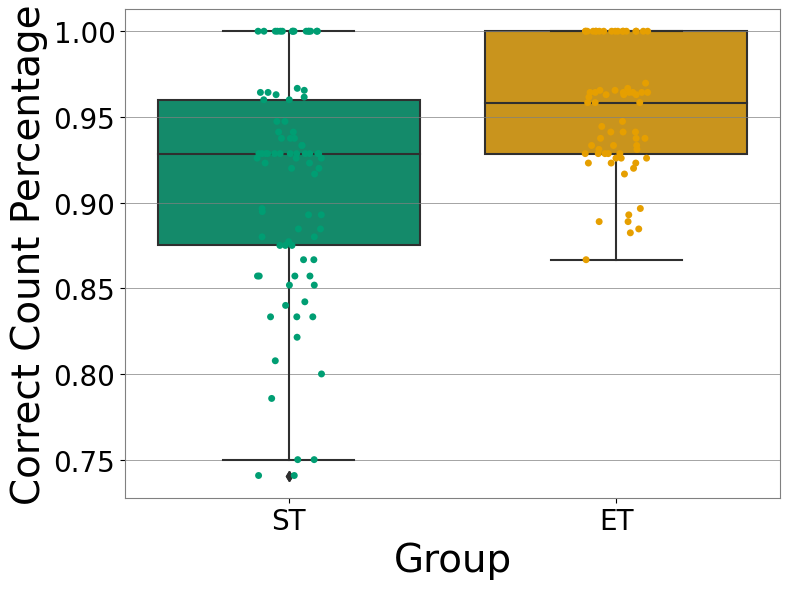

In [60]:

# Assuming your DataFrame is stored as 'df'
df = stars_All_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y='Count', palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y='Count', jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
# plt.title('Automaticity test - All Pilots', fontsize=16)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Correct Count Percentage', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Show grid in the background with grey color
plt.grid(True, which='both', axis='y', color='grey', linestyle='-', linewidth=0.5)

for spine in plt.gca().spines.values():
    spine.set_edgecolor('grey')  # Set the frame color to black
    # spine.set_linewidth(1.5)  # Optional: Adjust line width of the frame

# Show the plot
plt.tight_layout()
plt.savefig('Automaticity test - All.png')  # Save as PNG (you can change the file format)

plt.show()


In [61]:
stars_All_cleaned

,subId,Count,Presses,Group,Pilot,0,Group.1
0,64a67fb0aa154e67c58b9707,0.933333,0.915663,ST,1,NaN,NaN
1,64a67fb0aa154e67c58b9708,0.928571,0.768293,ST,1,NaN,NaN
2,64a67fb0aa154e67c58b9709,0.941176,0.817073,ST,1,NaN,NaN
3,64a67fb0aa154e67c58b970a,0.875000,0.855422,ST,1,NaN,NaN
4,64a67fb0aa154e67c58b970b,0.842105,0.722892,ST,1,NaN,NaN
...,...,...,...,...,...,...,...
152,6645c9cfd2c8fb647d0af397,0.964286,0.952381,ET,5,NaN,NaN
153,6645c9cfd2c8fb647d0af398,0.933333,0.904762,ET,5,NaN,NaN
154,6645c9cfd2c8fb647d0af39a,0.964286,0.914634,ET,5,NaN,NaN
156,6645c9cfd2c8fb647d0af39e,0.964286,0.743902,ET,5,NaN,NaN


In [62]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load your data
df = stars_All_cleaned  # Replace with actual dataframe variable

# Fit a Generalized Linear Mixed Model (GLMM)
model = smf.mixedlm("Count ~ Group", df, groups=df["Pilot"], re_formula="~1").fit()

# Print results
print(model.summary())


         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Count   
No. Observations:  154     Method:             REML    
No. Groups:        5       Scale:              0.0030  
Min. group size:   23      Log-Likelihood:     221.3003
Max. group size:   39      Converged:          No      
Mean group size:   30.8                                
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    0.953    0.007 144.354 0.000  0.940  0.966
Group[T.ST] -0.041    0.009  -4.597 0.000 -0.058 -0.023
Group Var    0.000                                     



/Users/maya/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/maya/anaconda3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/maya/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/maya/anaconda3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/maya/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  war

In [63]:
import numpy as np

# Extract coefficient and standard deviation of the outcome variable
beta = model.fe_params["Group[T.ST]"]
std_dev = np.std(stars_All_cleaned["Count"])

# Compute standardized beta
beta_standardized = beta / std_dev
print(f"Standardized Beta (Effect Size): {beta_standardized:.3f}")


Standardized Beta (Effect Size): -0.702


In [64]:
stars_All_cleaned[stars_All_cleaned['Group']=='ET'].describe()

,Count,Presses,Pilot,0
count,69.000000,69.000000,69.000000,10.000000
mean,0.953045,0.838662,2.840580,0.946876
std,0.035909,0.144431,1.481486,0.042626
min,0.866667,0.000000,1.000000,0.866667
25%,0.928571,0.797101,1.000000,0.928571
50%,0.958333,0.867647,3.000000,0.937255
75%,1.000000,0.914634,4.000000,0.986842
max,1.000000,1.000000,5.000000,1.000000


In [65]:
stars_All_cleaned

,subId,Count,Presses,Group,Pilot,0,Group.1
0,64a67fb0aa154e67c58b9707,0.933333,0.915663,ST,1,NaN,NaN
1,64a67fb0aa154e67c58b9708,0.928571,0.768293,ST,1,NaN,NaN
2,64a67fb0aa154e67c58b9709,0.941176,0.817073,ST,1,NaN,NaN
3,64a67fb0aa154e67c58b970a,0.875000,0.855422,ST,1,NaN,NaN
4,64a67fb0aa154e67c58b970b,0.842105,0.722892,ST,1,NaN,NaN
...,...,...,...,...,...,...,...
152,6645c9cfd2c8fb647d0af397,0.964286,0.952381,ET,5,NaN,NaN
153,6645c9cfd2c8fb647d0af398,0.933333,0.904762,ET,5,NaN,NaN
154,6645c9cfd2c8fb647d0af39a,0.964286,0.914634,ET,5,NaN,NaN
156,6645c9cfd2c8fb647d0af39e,0.964286,0.743902,ET,5,NaN,NaN


### Stars Presses

In [66]:
stars_All = stars_All.set_index('subId')

In [67]:
# Assuming your DataFrame is stored as 'df'
df = stars_All

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Presses'].describe()

# Calculating IQR and identifying outliers

# Apply the function to each group
outliers_stars_presses = df.groupby('Group')['Presses'].apply(find_outliers)

# Print outliers
print(outliers_stars_presses)



Group  subId                   
ET     65ba0c38d2c8fb647d0ae795    0.594203
       65ba0d2bd2c8fb647d0ae7a3    0.608696
       6645c9cfd2c8fb647d0af38f    0.000000
       6649b980d2c8fb647d0af409    0.380952
ST     64f9b20dd2c8fb647d0adfbe    0.463768
Name: Presses, dtype: float64


In [68]:
outliers_stars_presses = pd.DataFrame(outliers_stars_presses).reset_index()

In [69]:
outliers_stars_presses_subIds = outliers_stars_presses['subId']
stars_All = stars_All.reset_index()

In [70]:
stars_All_cleaned = stars_All[~stars_All['subId'].isin(outliers_stars_presses_subIds)]

In [71]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(stars_All_cleaned[stars_All_cleaned['Group']=='ST']['Presses']))
print("Shapiro-Wilk test for 'ET':", shapiro(stars_All_cleaned[stars_All_cleaned['Group']=='ET']['Presses']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9458503723144531, pvalue=0.0012671585427597165)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9750261306762695, pvalue=0.18877266347408295)


In [72]:
group_ST = stars_All_cleaned[stars_All_cleaned['Group']=='ST']['Presses']
group_ET = stars_All_cleaned[stars_All_cleaned['Group']=='ET']['Presses']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")



Mann-Whitney U test: U = 2548.50, p-value = 0.172332
Effect size (r) = 0.110


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82502/2727707497.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


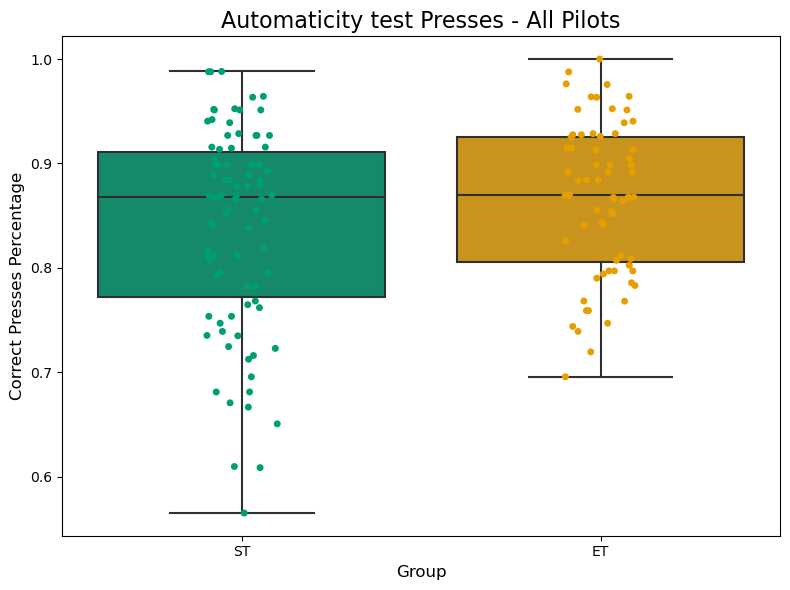

In [73]:

# Assuming your DataFrame is stored as 'df'
df = stars_All_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y='Presses', palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y='Presses', jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
plt.title('Automaticity test Presses - All Pilots', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Correct Presses Percentage', fontsize=12)

# Show the plot
plt.tight_layout()
plt.savefig('Automaticity test Presses - All.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


## Last & Dev

In [116]:
dev_lastANDtest.to_csv('dev_lastANDtest.csv')

In [118]:
dev_lastANDtest = dev_lastANDtest.drop(index=outliers_stars_count['subId'])

In [121]:
group_ST = dev_lastANDtest[dev_lastANDtest['Group']=='ST']['dev_percent']
group_ET = dev_lastANDtest[dev_lastANDtest['Group']=='ET']['dev_percent']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")


Mann-Whitney U test: U = 3715.50, p-value = 0.447649
Effect size (r) = 0.059


In [ ]:
df['dev_percent'].to_frame().groupby(df['dev_percent'] / 0.01).size().rename("values").plot(logy=True)

## Factor analysis

In [123]:
stars_All_cleaned = stars_All_cleaned.set_index('subId')

In [124]:
df_factors = pd.concat([dev_lastANDtest,stars_All_cleaned], axis=1).dropna()

## RT stars & training

In [128]:
rt_stars_training = rt_stars_training.set_index('subId')#.to_csv('rt_stars_training.csv')

In [129]:
# Assuming your DataFrame is stored as 'df'
df = rt_stars_training

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby(['Group','step'])['MeanRT'].describe()

# Calculating IQR and identifying outliers

# Apply the function to each group
outliers_rt_stars = df.groupby(['step','Group'])['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_rt_stars)


step      Group  subId                   
Training  ET     6645c9cfd2c8fb647d0af389    383.518519
          ST     6645cb96d2c8fb647d0af3a7    281.717949
                 6645cb96d2c8fb647d0af3a7    328.166667
Name: MeanRT, dtype: float64


In [130]:
outliers_rt_stars

step      Group  subId                   
Training  ET     6645c9cfd2c8fb647d0af389    383.518519
          ST     6645cb96d2c8fb647d0af3a7    281.717949
                 6645cb96d2c8fb647d0af3a7    328.166667
Name: MeanRT, dtype: float64

In [131]:
outliers_rt_stars = pd.DataFrame(outliers_rt_stars).reset_index()
outliers_rt_stars_subIds = outliers_rt_stars['subId']
rt_stars_training = rt_stars_training.reset_index()

In [132]:
rt_stars_training_cleaned = rt_stars_training[~rt_stars_training['subId'].isin(outliers_rt_stars_subIds)]

In [133]:
from scipy.stats import shapiro

# Filter the dataset for Group = 'ST' and Step = 'Stars'
subset = rt_stars_training[(rt_stars_training['Group'] == 'ST') & 
                           (rt_stars_training['step'] == 'Training')]['MeanRT']

# Perform the Shapiro-Wilk test
stat, p_value = shapiro(subset)

# Print the result
print(f"Shapiro-Wilk Test: W = {stat:.4f}, p = {p_value:.4f}")


Shapiro-Wilk Test: W = 0.9639, p = 0.0001


### It's all in R

In [134]:
rt_stars_training_cleaned = rt_stars_training_cleaned.dropna()

In [135]:
rt_stars_training_cleaned.to_csv('rt_stars_training.csv')

In [136]:
rt_stars_training_cleaned[(rt_stars_training_cleaned['Group'] == 'ST') & 
                           (rt_stars_training_cleaned['step'] == 'Stars')].describe()

,MeanRT,Pilot
count,175.000000,175.000000
mean,715.961121,2.777143
std,80.554301,1.313739
min,516.647059,1.000000
25%,658.705051,2.000000
50%,713.400000,3.000000
75%,772.971795,4.000000
max,913.187500,5.000000


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82502/3364323576.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.barplot(


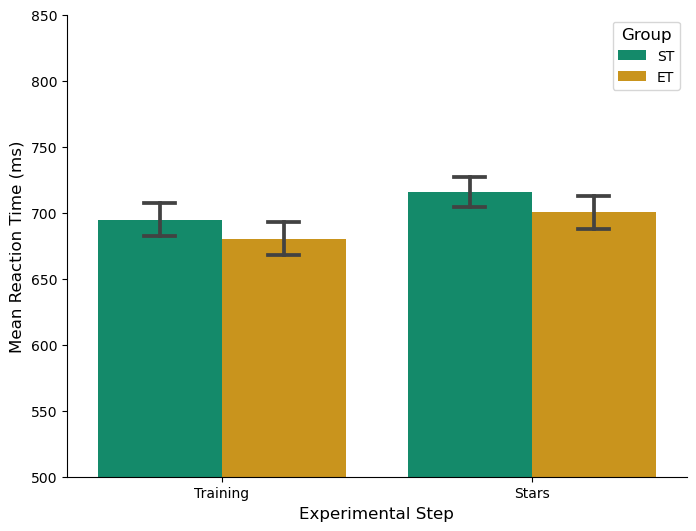

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = rt_stars_training_cleaned  # Replace with your actual DataFrame

# Define custom colors for groups
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Define custom order for Step (flip order)
step_order = ["Training", "Stars"]  # Training first, then Stars

# Set figure size
plt.figure(figsize=(8, 6))

# Create the bar plot with flipped Step order
ax = sns.barplot(
    data=df,
    x="step",  # X-axis: Step (now flipped order)
    y="MeanRT",  # Y-axis: Mean Reaction Time
    hue="Group",  # Different colors for ST and ET groups
    palette=custom_palette,  # Apply custom colors
    ci=95,  # 95% confidence interval error bars
    capsize=0.1,  # Small caps on error bars
    order=step_order  # Set custom order for Step
)

# Set axis limits
plt.ylim(500, 850)

# Customize axis labels and title
ax.set_xlabel("Experimental Step", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Mean Reaction Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

# Adjust legend
plt.legend(title="Group", title_fontsize=12, fontsize=10)

# Remove unnecessary spines for better aesthetics
sns.despine()

# Save the figure
plt.savefig("response_time_stars_flipped.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()


## Qs and stars

In [247]:
ques = pd.read_excel('/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/analysis_scripts/Qs with SubIds.xlsx')

In [248]:
ques = ques.dropna()
ques = ques.set_index('subId')

In [249]:
ques = pd.concat([ques, dev_lastANDtest['Group']], axis = 1).dropna()#drop(columns=['Group'])

In [250]:
len(ques)
# ques

155

In [241]:
stars_All_cleaned.loc[stars_All_cleaned['Count'].isna(), 'Count'] = stars_All_cleaned['0']

In [242]:
# Ensure that only the automaticity question columns are passed as a DataFrame (2D)
df_automaticity = stars_All_cleaned[['Count']].dropna()  # Remove missing values

# Check the shape of df_automaticity (should be [n_samples, n_features])
print(df_automaticity.shape)  # Should print (num_participants, num_questions)


(154, 1)


KMO Test: 0.748 (Should be > 0.6)
Bartlett's Test: χ²=156.691, p=0.000 (p should be < 0.05)


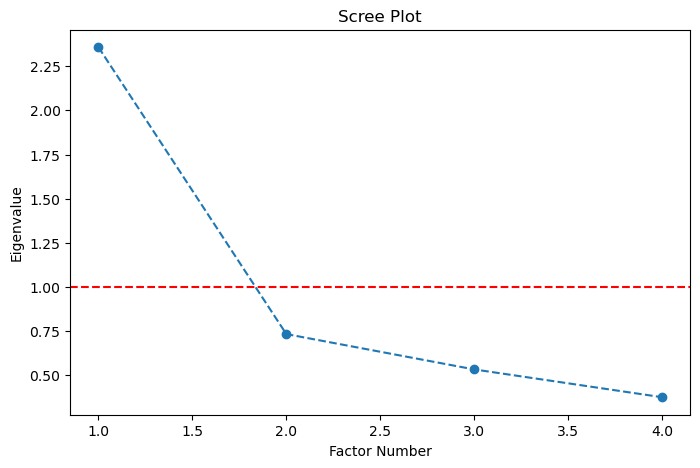

Number of factors to extract: 1

Factor Loadings:
                                                    Factor 1
I pressed automatically                            -0.714894
I pressed without having to consciously remembe... -0.598954
I pressed without thinking.                        -0.859552
I started clicking before I realized I was doin... -0.518391


/Users/maya/anaconda3/lib/python3.10/site-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(


In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo

# Load the dataset
df = ques

# Select only response columns (excluding non-numeric columns like 'pilot' and 'Group')
response_columns = [
    "I pressed automatically",
    "I pressed without having to consciously remember to do it.",
    "I pressed without thinking.",
    "I started clicking before I realized I was doing it."
]
df_responses = df[response_columns]

# Check for missing values and handle them
df_responses = df_responses.dropna()

# Check factorability with KMO and Bartlett’s test
kmo_all, kmo_model = calculate_kmo(df_responses)
bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(df_responses)

print(f"KMO Test: {kmo_model:.3f} (Should be > 0.6)")
print(f"Bartlett's Test: χ²={bartlett_chi2:.3f}, p={bartlett_p:.3f} (p should be < 0.05)")

# Perform Eigenvalue analysis
fa = FactorAnalyzer(n_factors=len(response_columns), rotation=None)
fa.fit(df_responses)
eigenvalues, _ = fa.get_eigenvalues()

# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker="o", linestyle="--")
plt.xlabel("Factor Number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.axhline(y=1, color="r", linestyle="--")  # Kaiser's criterion (eigenvalues > 1)
plt.show()

# Decide number of factors (choose factors with eigenvalues > 1)
n_factors = sum(eigenvalues > 1)
print(f"Number of factors to extract: {n_factors}")

# Perform Factor Analysis with chosen number of factors
fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa.fit(df_responses)

# Get factor loadings
factor_loadings = pd.DataFrame(fa.loadings_, index=response_columns, columns=[f"Factor {i+1}" for i in range(n_factors)])

# Save results to CSV (optional)
factor_loadings.to_csv("factor_loadings.csv")

# Print results
print("\nFactor Loadings:")
print(factor_loadings)


In [244]:
# ques = ques.set_index('subId')
ques["Automaticity_Score"] = df_responses.mean(axis=1)
ques['Count_Score'] = stars_All_cleaned['Count']

# len(ques["Automaticity_Score"].dropna())
# ques['Count_Score'] = stars_All_cleaned['Count']
# len(ques["Count_Score"].dropna())

In [245]:
# ques = ques.dropna()
# Assuming your DataFrame is stored as 'df'
df = ques

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Count_Score'].describe()

# Calculating IQR and identifying outliers

# Apply the function to each group
outliers_Automaticity_Score = df.groupby('Group')['Count_Score'].apply(find_outliers)

# Print outliers
print(outliers_Automaticity_Score)

Series([], Name: Count_Score, dtype: float64)


In [246]:
outliers_Automaticity_Score = pd.DataFrame(outliers_Automaticity_Score).reset_index()
outliers_Automaticity_Score_subId = outliers_Automaticity_Score['subId']
ques = ques.reset_index()

KeyError: 'subId'

In [236]:
ques = ques[~ques['subId'].isin(outliers_Automaticity_Score_subId)]

In [237]:
# len(ques)
# len(ques['Count_Score'])
len(ques['Automaticity_Score'].dropna())

151

In [239]:
# If Group Var ≈ 0, re-run your model without pilot as a random effect:
model = smf.ols("Count_Score ~ Automaticity_Score * Group", data=ques).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            Count_Score   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     8.481
Date:                Wed, 23 Apr 2025   Prob (F-statistic):           4.44e-05
Time:                        14:17:02   Log-Likelihood:                 179.25
No. Observations:                 105   AIC:                            -350.5
Df Residuals:                     101   BIC:                            -339.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [217]:
print(f"F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.2f}, p = {model.f_pvalue:.3g}")


F(3, 101) = 8.48, p = 4.44e-05


In [218]:
model_st = smf.ols('Count_Score ~ Automaticity_Score', data=df[df['Group'] == 'ET']).fit()
print(model_st.summary())


                            OLS Regression Results                            
Dep. Variable:            Count_Score   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.8887
Date:                Wed, 23 Apr 2025   Prob (F-statistic):              0.350
Time:                        14:14:00   Log-Likelihood:                 101.91
No. Observations:                  51   AIC:                            -199.8
Df Residuals:                      49   BIC:                            -196.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9689      0

In [158]:
print(f"F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.2f}, p = {model.f_pvalue:.3g}")


F(3, 101) = 8.48, p = 4.44e-05


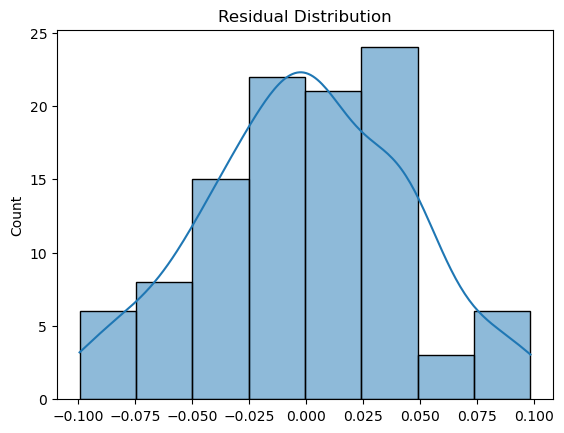

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(model.resid, kde=True)
plt.title("Residual Distribution")
plt.show()


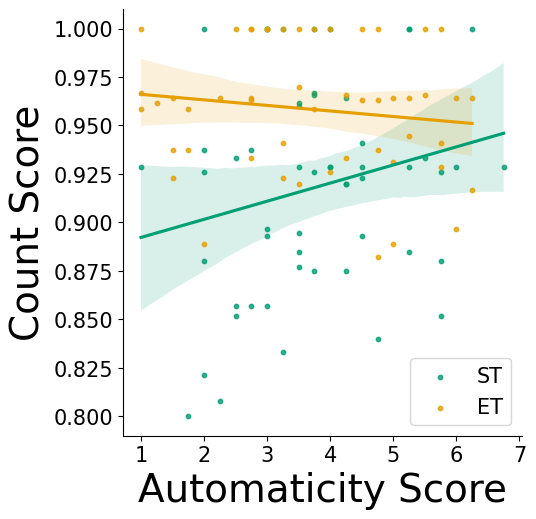

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define custom colors for groups
palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the plot with custom palette and smaller dots
sns.lmplot(x="Automaticity_Score", y="Count_Score", hue="Group", data=ques, 
           palette=palette, scatter_kws={"s": 10}, legend=False)  # 's' controls the dot size

# Add a title
# plt.title("Interaction: Does Group Modify the Effect of Automaticity Score?")
plt.xlabel('Automaticity Score', fontsize=28)
plt.ylabel('Count Score', fontsize=28)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(loc='lower right', fontsize=15)
plt.savefig('Automaticity and Count', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

# Show the plot
plt.show()


In [162]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(ques[ques['Group']=='ST']['Automaticity_Score']))
print("Shapiro-Wilk test for 'ET':", shapiro(ques[ques['Group']=='ET']['Automaticity_Score']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9875895380973816, pvalue=0.6875486969947815)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.970816433429718, pvalue=0.07346426695585251)


In [163]:
from scipy.stats import ttest_ind

# Select the two groups
group_1 = ques[ques["Group"] == "ST"][["I pressed automatically", "I pressed without having to consciously remember to do it.", "I pressed without thinking.", "I started clicking before I realized I was doing it."]]
group_2 = ques[ques["Group"] == "ET"][["I pressed automatically", "I pressed without having to consciously remember to do it.", "I pressed without thinking.", "I started clicking before I realized I was doing it."]]

# Perform t-tests for each question
for col in group_1.columns:
    t_stat, p_value = ttest_ind(group_1[col], group_2[col])
    print(f"T-test for '{col}': t={t_stat:.3f}, p={p_value:.3f}")


T-test for 'I pressed automatically': t=0.276, p=0.783
T-test for 'I pressed without having to consciously remember to do it.': t=-0.135, p=0.893
T-test for 'I pressed without thinking.': t=1.073, p=0.285
T-test for 'I started clicking before I realized I was doing it.': t=0.576, p=0.565
